# ⭐ Bài tập về nhà 3 — Đo cả pipeline: YOLO26n ONNX trên CPU
Export `yolo26n.pt` sang ONNX theo hai cách rồi đo latency **trên CPU**:

| Head | Lệnh export | Output của graph | Hậu xử lý |
|---|---|---|---|
| one-to-many + NMS | `export(format="onnx")` (mặc định `nms=None`) | `(1, 84, 8400)` | NMS chạy ngoài graph |
| one-to-one (NMS-free) | `export(format="onnx", nms=False)` | top-300 `(1, 300, 6)` | chỉ lọc theo conf |

Mỗi head đo ở **conf 0.25** (triển khai) và **conf 0.001** (lúc tính mAP), trên `bus.jpg` và trên một "cảnh đông" ghép 2×2 từ `bus.jpg`.
Notebook chạy trên **runtime CPU** (không cần GPU): `Thời gian chạy → Chạy tất cả`.

In [1]:
%pip install -q "ultralytics==8.4.171" "onnx>=1.12.0,<2.0.0" "onnxslim>=0.1.82" onnxruntime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.5/244.5 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatibl

In [2]:
import json, os, platform, shutil
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import onnx
import onnxruntime as ort
import torch
import ultralytics
from IPython.display import Markdown, display
from ultralytics import YOLO
from ultralytics.data.augment import LetterBox

IMG_BUS = str(Path(ultralytics.__file__).parent / "assets" / "bus.jpg")
CPU_NAME = next((l.split(":", 1)[1].strip() for l in open("/proc/cpuinfo") if l.startswith("model name")), platform.processor())
VERSIONS = {"ultralytics": ultralytics.__version__, "torch": torch.__version__, "onnxruntime": ort.__version__, "onnx": onnx.__version__}
print(" | ".join(f"{k} {v}" for k, v in VERSIONS.items()))
print(f"CPU: {CPU_NAME} | {os.cpu_count()} luồng | GPU: {torch.cuda.is_available()}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
ultralytics 8.4.171 | torch 2.11.0+cu130 | onnxruntime 1.30.0 | onnx 1.23.1
CPU: Intel(R) Xeon(R) CPU @ 2.00GHz | 2 luồng | GPU: True


## 1. Export hai file ONNX
Hai lần export cùng ghi ra `yolo26n.onnx`, nên đổi tên ngay sau mỗi lần. Ultralytics ghi cờ `end2end` vào metadata của file ONNX;
lúc chạy, nó đọc cờ này để biết có cần NMS hay không.

In [3]:
ONNX, ONNX_INFO = {}, {}
for name, kw in (("o2m", {}), ("o2o", {"nms": False})):
    path = YOLO("yolo26n.pt").export(format="onnx", imgsz=640, device="cpu", **kw)
    ONNX[name] = shutil.move(path, f"yolo26n_{name}.onnx")

for name, path in ONNX.items():
    sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
    meta = {p.key: p.value for p in onnx.load(path).metadata_props}
    ONNX_INFO[name] = {"input": sess.get_inputs()[0].shape, "output": sess.get_outputs()[0].shape,
                       "end2end": meta.get("end2end"), "MB": round(os.path.getsize(path) / 1e6, 2)}
    print(f"{path}: {ONNX_INFO[name]}")

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO26n summary (fused): 120 layers, 2,408,932 parameters, 0 gradients, 5.5 GFLOPs

PyTorch: starting from 'yolo26n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.3 MB)

ONNX: starting export with onnx 1.23.1 opset 18...
ONNX: slimming with onnxslim 0.1.97...
ONNX: export success ✅ 10.2s, saved as 'yolo26n.onnx' (9.5 MB)

Export complete (12.0s)
Results saved to /content/yolo26n.onnx
Predict:         yolo predict task=detect model=yolo26n.onnx imgsz=640 
Validate:        yolo val task=detect model=yolo26n.onnx imgsz=640   
Visualize:       https://netron.app
Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,408,932 parameters, 0 gradients, 5.5 GFLOPs

PyT

In [4]:
# Kiểm tra nhanh: hai file ONNX phải đếm ra cùng số người / xe như notebook chính (4 người, 1 xe buýt)
onnx_o2m = YOLO(ONNX["o2m"], task="detect")
onnx_o2o = YOLO(ONNX["o2o"], task="detect")
for name, m, kw in (("one-to-many + NMS", onnx_o2m, {"iou": 0.7}), ("one-to-one NMS-free", onnx_o2o, {"nms": False})):
    r = m.predict(IMG_BUS, device="cpu", conf=0.25, verbose=False, **kw)[0]
    print(f"ONNX {name:20s}: {len(r.boxes)} box →", {r.names[int(k)]: int((r.boxes.cls == k).sum()) for k in r.boxes.cls.unique()})

Loading yolo26n_o2m.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.30.0 with CPUExecutionProvider
ONNX one-to-many + NMS   : 5 box → {'person': 4, 'bus': 1}
Loading yolo26n_o2o.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.30.0 with CPUExecutionProvider
ONNX one-to-one NMS-free : 5 box → {'person': 4, 'bus': 1}


## 2. Có bao nhiêu dự đoán phải đưa vào NMS?
Chạy thẳng graph ONNX bằng onnxruntime trên ảnh đã letterbox về 640×640 (ONNX export tĩnh), đếm số dự đoán vượt ngưỡng conf.

In [5]:
def count_candidates(img_path):
    img = LetterBox((640, 640), auto=False, stride=32)(image=cv2.imread(img_path))
    x = np.ascontiguousarray(img[..., ::-1].transpose(2, 0, 1))[None].astype(np.float32) / 255
    res = {}
    for name, path in ONNX.items():
        sess = ort.InferenceSession(path, providers=["CPUExecutionProvider"])
        o = sess.run(None, {sess.get_inputs()[0].name: x})[0][0]
        if name == "o2m":                                                 # (4 + 80, 8400): 4 toạ độ + điểm từng class
            o = o if o.shape[0] < o.shape[1] else o.T
            score = o[4:].max(0)
        else:                                                             # (300, 6) = x1, y1, x2, y2, score, cls
            score = o[:, 4]
        res[name] = {f"conf {c}": int((score > c).sum()) for c in (0.25, 0.001)}
    return res


bus = cv2.imread(IMG_BUS)
cv2.imwrite("crowd.jpg", np.vstack([np.hstack([bus, bus]), np.hstack([bus, bus])]))   # "cảnh đông": 4 bản bus.jpg trong một khung
CANDIDATES = {"bus.jpg": count_candidates(IMG_BUS), "crowd.jpg": count_candidates("crowd.jpg")}
print(json.dumps(CANDIDATES, indent=2))

{
  "bus.jpg": {
    "o2m": {
      "conf 0.25": 48,
      "conf 0.001": 620
    },
    "o2o": {
      "conf 0.25": 5,
      "conf 0.001": 177
    }
  },
  "crowd.jpg": {
    "o2m": {
      "conf 0.25": 173,
      "conf 0.001": 1379
    },
    "o2o": {
      "conf 0.25": 18,
      "conf 0.001": 300
    }
  }
}


## 3. Đo latency trên CPU
Giống hàm `bench` của notebook chính: warm-up 1 lần rồi lấy trung bình 30 lần, đọc thời gian từng giai đoạn từ `Results.speed`.

In [6]:
def bench(model, img, n=30, **kw):
    """Thời gian trung bình (ms) từng giai đoạn, chạy trên CPU."""
    model.predict(img, device="cpu", verbose=False, **kw)                  # warm-up
    acc = {"preprocess": 0.0, "inference": 0.0, "postprocess": 0.0}
    for _ in range(n):
        r = model.predict(img, device="cpu", verbose=False, **kw)[0]
        for k in acc:
            acc[k] += r.speed[k] / n
    return {f"{k} (ms)": round(v, 2) for k, v in acc.items()} | {"tổng (ms)": round(sum(acc.values()), 2), "số box": len(r.boxes)}


def show_table(rows, title):
    cols = list(rows[0])
    md = f"**{title}**\n\n| " + " | ".join(cols) + " |\n|" + "---|" * len(cols) + "\n"
    md += "\n".join("| " + " | ".join(f"{r[c]:.2f}" if isinstance(r[c], float) else str(r[c]) for c in cols) + " |" for r in rows)
    display(Markdown(md))


HEADS = (("one-to-many + NMS", onnx_o2m, {"iou": 0.7}), ("one-to-one NMS-free", onnx_o2o, {"nms": False}))
LATENCY_CPU = {img: [{"Head": h, "conf": str(c)} | bench(m, img, conf=c, **kw) for h, m, kw in HEADS for c in (0.25, 0.001)]
               for img in (IMG_BUS, "crowd.jpg")}
for img, rows in LATENCY_CPU.items():
    show_table(rows, f"YOLO26n ONNX trên CPU — {Path(img).name} (trung bình 30 lần)")

**YOLO26n ONNX trên CPU — bus.jpg (trung bình 30 lần)**

| Head | conf | preprocess (ms) | inference (ms) | postprocess (ms) | tổng (ms) | số box |
|---|---|---|---|---|---|---|
| one-to-many + NMS | 0.25 | 4.87 | 76.41 | 1.37 | 82.65 | 5 |
| one-to-many + NMS | 0.001 | 4.60 | 75.59 | 2.06 | 82.25 | 186 |
| one-to-one NMS-free | 0.25 | 5.00 | 81.68 | 0.44 | 87.12 | 5 |
| one-to-one NMS-free | 0.001 | 6.50 | 103.15 | 0.65 | 110.30 | 177 |

**YOLO26n ONNX trên CPU — crowd.jpg (trung bình 30 lần)**

| Head | conf | preprocess (ms) | inference (ms) | postprocess (ms) | tổng (ms) | số box |
|---|---|---|---|---|---|---|
| one-to-many + NMS | 0.25 | 5.45 | 83.12 | 1.56 | 90.13 | 18 |
| one-to-many + NMS | 0.001 | 4.91 | 76.45 | 4.69 | 86.04 | 300 |
| one-to-one NMS-free | 0.25 | 6.01 | 93.57 | 0.46 | 100.04 | 18 |
| one-to-one NMS-free | 0.001 | 5.50 | 87.90 | 0.51 | 93.90 | 300 |

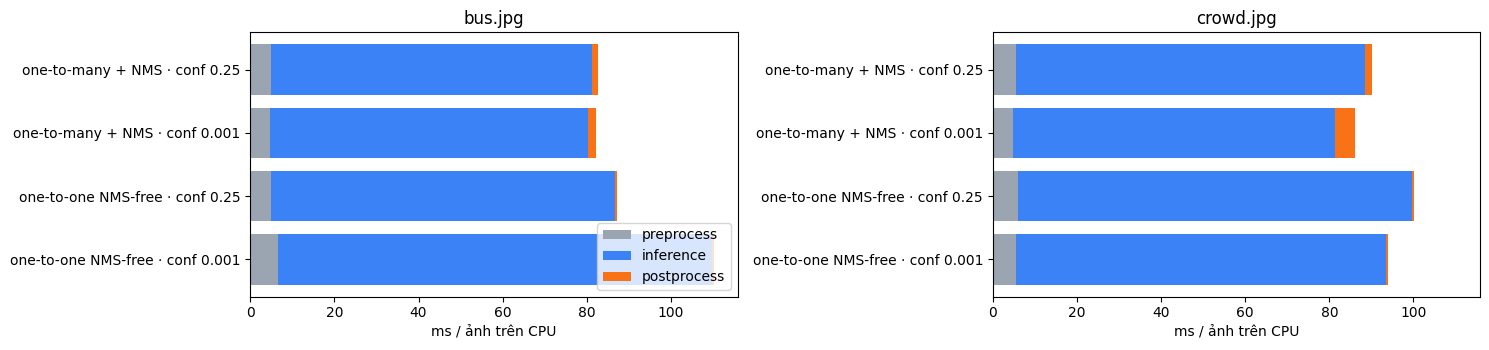

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 3.6), sharex=True)
for ax, (img, rows) in zip(axes, LATENCY_CPU.items()):
    labels, left = [f"{r['Head']} · conf {r['conf']}" for r in rows], np.zeros(len(rows))
    for k, color in (("preprocess (ms)", "#9aa5b1"), ("inference (ms)", "#3b82f6"), ("postprocess (ms)", "#f97316")):
        v = np.array([r[k] for r in rows])
        ax.barh(labels, v, left=left, color=color, label=k.replace(" (ms)", ""))
        left += v
    ax.invert_yaxis(); ax.set_title(Path(img).name); ax.set_xlabel("ms / ảnh trên CPU")
axes[0].legend(loc="lower right"); plt.tight_layout(); plt.show()

In [8]:
RESULT = {"cpu": CPU_NAME, "threads": os.cpu_count(), "versions": VERSIONS, "onnx": ONNX_INFO, "candidates": CANDIDATES,
          "latency_cpu": {Path(k).name: v for k, v in LATENCY_CPU.items()}}
Path("ket_qua_onnx.json").write_text(json.dumps(RESULT, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(RESULT, ensure_ascii=False, indent=2))

{
  "cpu": "Intel(R) Xeon(R) CPU @ 2.00GHz",
  "threads": 2,
  "versions": {
    "ultralytics": "8.4.171",
    "torch": "2.11.0+cu130",
    "onnxruntime": "1.30.0",
    "onnx": "1.23.1"
  },
  "onnx": {
    "o2m": {
      "input": [
        1,
        3,
        640,
        640
      ],
      "output": [
        1,
        84,
        8400
      ],
      "end2end": "False",
      "MB": 9.93
    },
    "o2o": {
      "input": [
        1,
        3,
        640,
        640
      ],
      "output": [
        1,
        300,
        6
      ],
      "end2end": "True",
      "MB": 9.94
    }
  },
  "candidates": {
    "bus.jpg": {
      "o2m": {
        "conf 0.25": 48,
        "conf 0.001": 620
      },
      "o2o": {
        "conf 0.25": 5,
        "conf 0.001": 177
      }
    },
    "crowd.jpg": {
      "o2m": {
        "conf 0.25": 173,
        "conf 0.001": 1379
      },
      "o2o": {
        "conf 0.25": 18,
        "conf 0.001": 300
      }
    }
  },
  "latency_cpu": {
    "bus

Nhận xét và so sánh với số đo trên GPU T4 của notebook chính: xem `submission/bao_cao_bai_tap_ve_nha.md` trong repo.